# Data Initialization


In [82]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

raw_df = pd.read_csv('weekly_player_stats_offense.csv')

In [83]:
# set fantasy points as targets 
# drop irrelevant / categorical features 
# condense samples to one per player - seasonal weekly average 
# make training-validation split 
# encode / normalize kept features 
# train / validate model 
# Remove features that have minimal impact on model performance 
# whatever the fuck else

# Categorical Stats
# position

# Numerical Stats
# week
# season
# passing_yards
# receiving_yards
# rushing_yards
# rush_touchdown
# pass_touchdown
# fumble_lost
# receptions
# interception

# Logically, we split the fantasy point stats between test and training and compare them against our model
# Target = fantasy_points_ppr

feature_labels = ['position', 'week', 'season', 'passing_yards', 'receiving_yards', 'rushing_yards', 'rush_touchdown', 'pass_touchdown',
				  	'fumble_lost', 'receptions', 'interception']
features = raw_df[feature_labels]

target_labels = ['fantasy_points_ppr']
y = raw_df[target_labels]

categorical_features = [col for col in raw_df.columns if not pd.api.types.is_numeric_dtype(raw_df[col])]
numerical_features = [col for col in raw_df.columns if pd.api.types.is_numeric_dtype(raw_df[col])]

print("Categorical Features: ", categorical_features)
print("Numerical Features: ", numerical_features)

# plot each categorical feature and numerical feature
# find and fill holes or remove if missing too much data

# create test dataframe
# test_df = pd.concat(raw_df[catgeorical] , raw_df[real_value])

# ohe categorical features
# normalize numerical features

# train test split
	# split based on avverge fantasy points ppr? or some other metric ? 

# stick into a model - xgboost / random forest / linear regression

# graph model perofrmances, start selecting features based on importance, correlation, etc to combine or remove 

#plt.figure(dpi=500)
#sns.heatmap(position_filtered_df.isnull() , cbar=False , cmap='viridis')
#plt.ylabel('Samples')
#plt.xlabel('Features')

#plt.show()

Categorical Features:  ['player_id', 'college', 'season_type', 'player_name', 'position', 'conference', 'division', 'team']
Numerical Features:  ['season', 'week', 'offense_snaps', 'offense_pct', 'team_offense_snaps', 'birth_year', 'draft_year', 'draft_round', 'draft_pick', 'draft_ovr', 'height', 'weight', 'depth_team', 'shotgun', 'no_huddle', 'qb_dropback', 'qb_scramble', 'pass_attempts', 'complete_pass', 'incomplete_pass', 'passing_yards', 'receiving_yards', 'yards_after_catch', 'rush_attempts', 'rushing_yards', 'tackled_for_loss', 'first_down_pass', 'first_down_rush', 'third_down_converted', 'third_down_failed', 'fourth_down_converted', 'fourth_down_failed', 'rush_touchdown', 'pass_touchdown', 'safety', 'interception', 'fumble', 'fumble_lost', 'fumble_forced', 'fumble_not_forced', 'fumble_out_of_bounds', 'receptions', 'targets', 'passing_air_yards', 'receiving_air_yards', 'receiving_touchdown', 'pass_attempts_redzone', 'complete_pass_redzone', 'pass_touchdown_redzone', 'pass_attempt

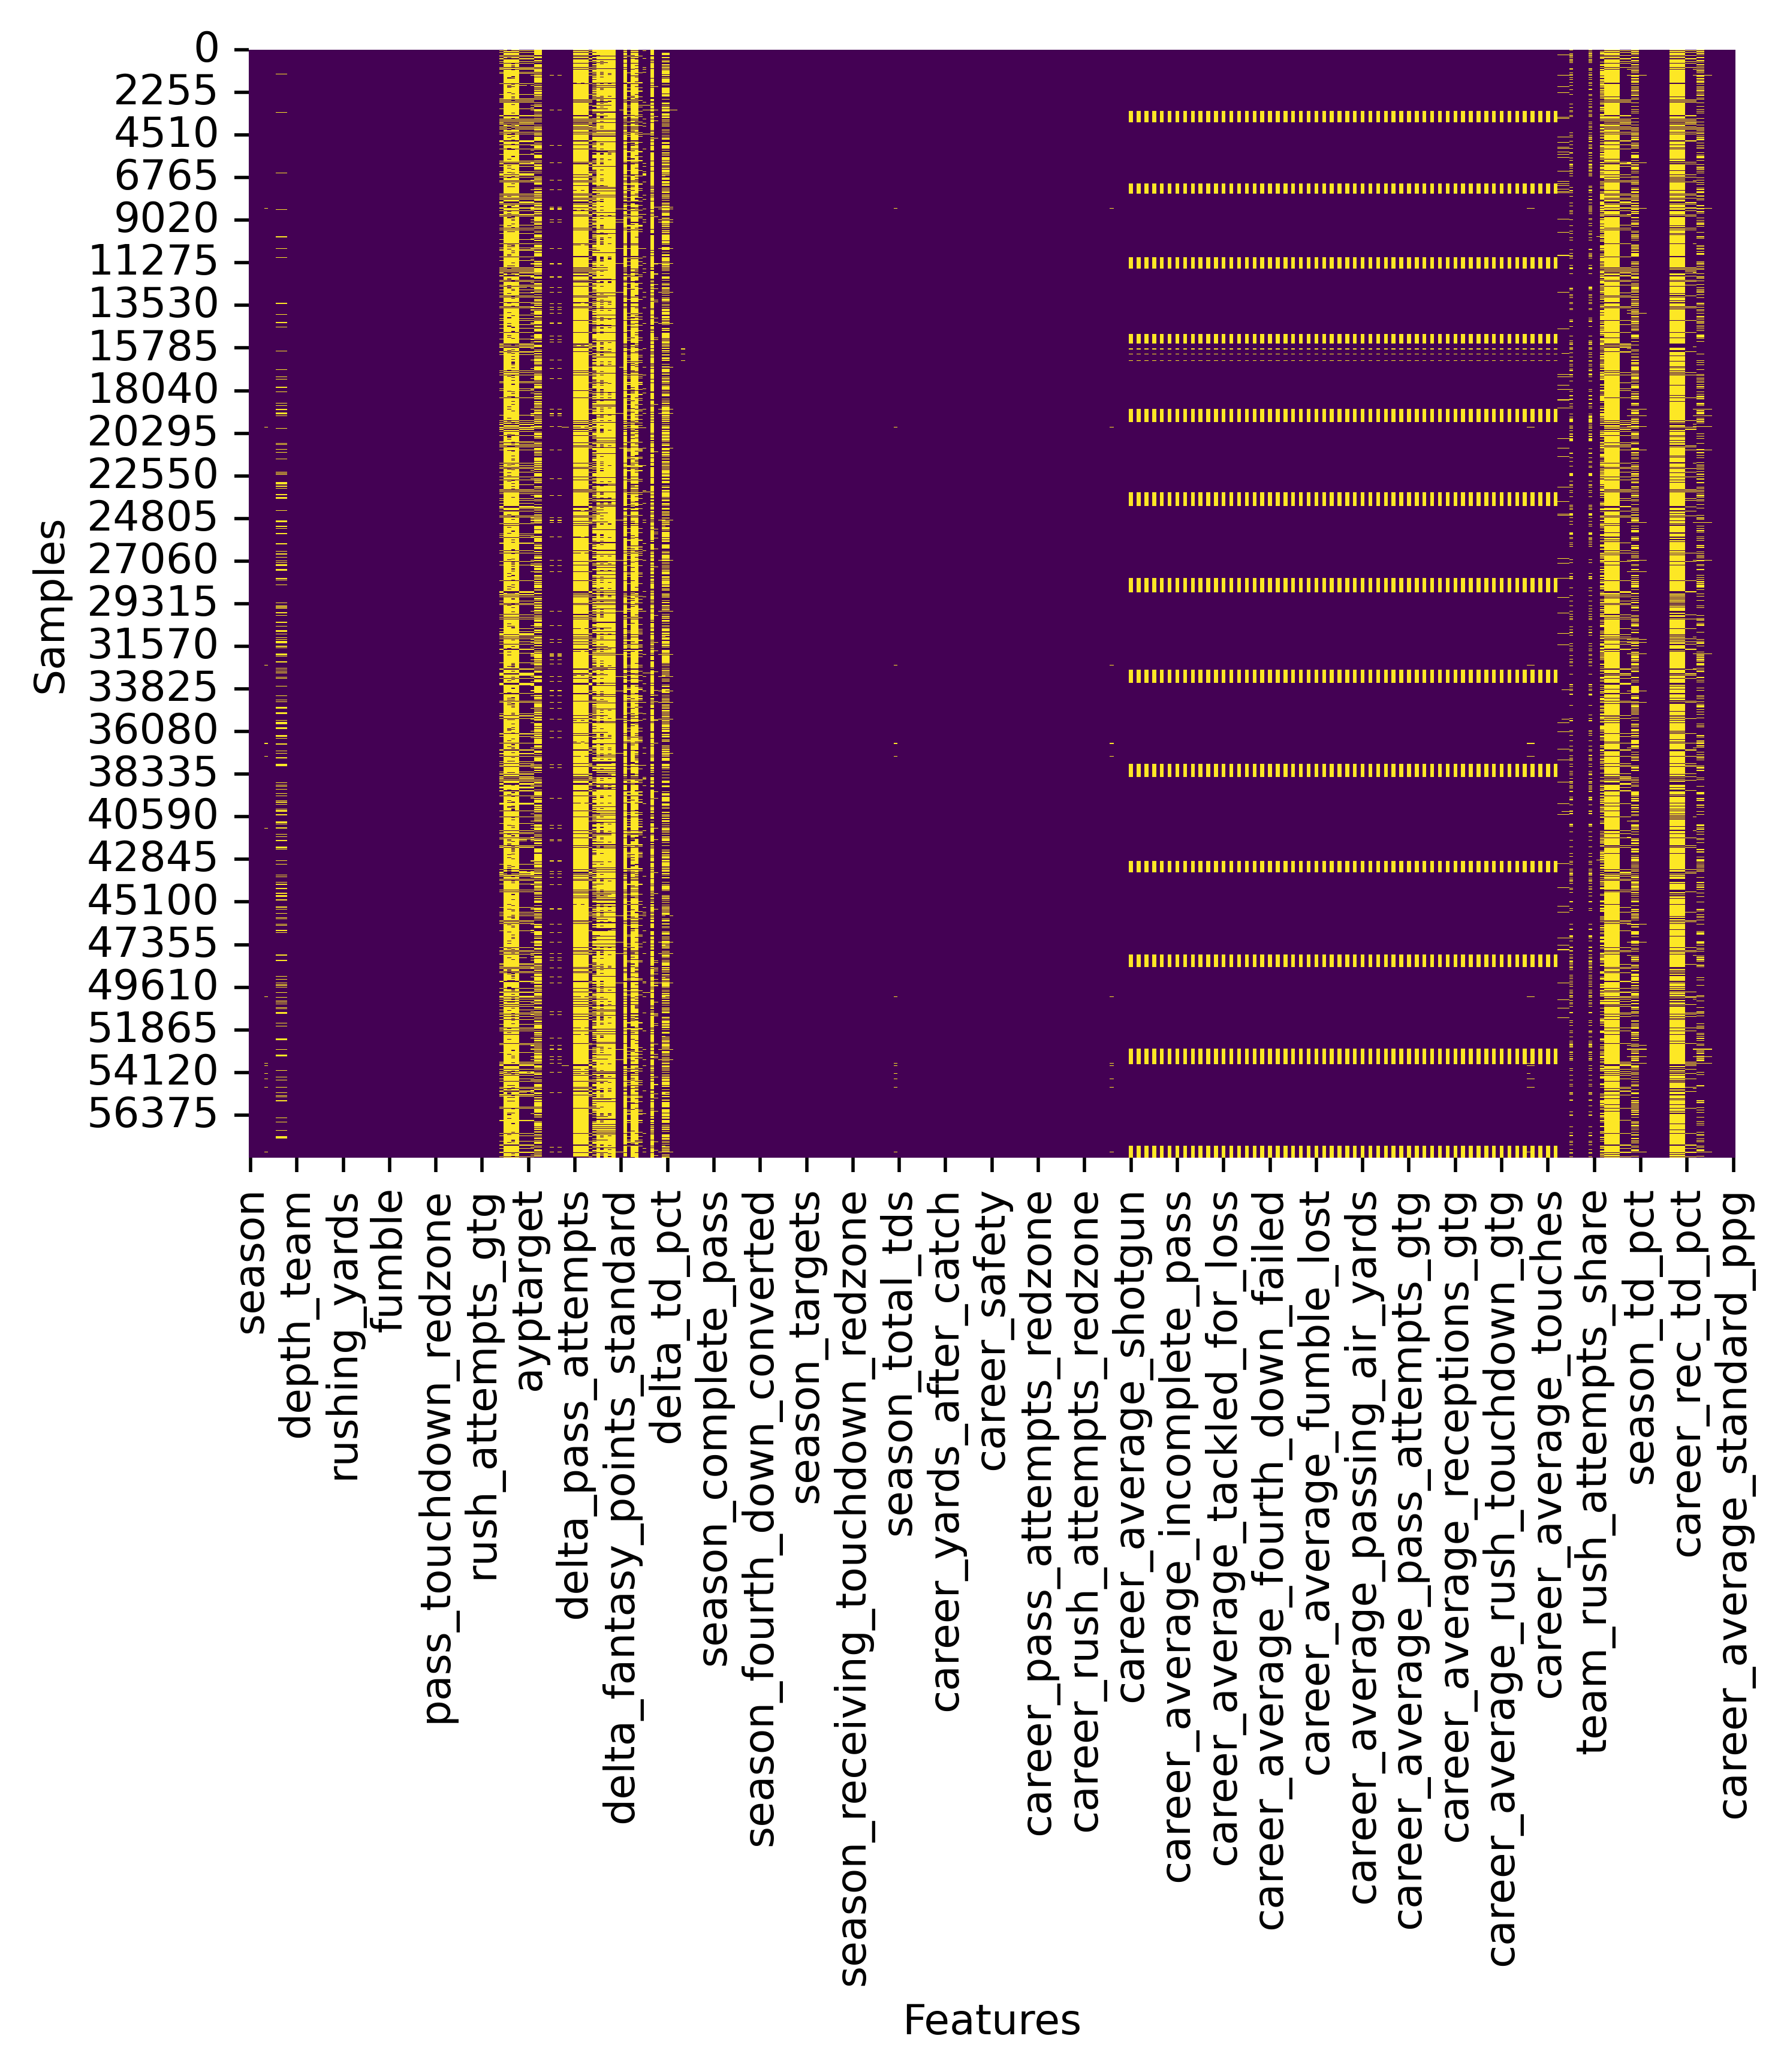

In [84]:
# Printing the heatmap to identify missing values in numerical features
plt.figure(dpi=500)
sns.heatmap(raw_df[numerical_features].isnull() , cbar=False , cmap='viridis')
plt.ylabel('Samples')
plt.xlabel('Features')
plt.show()

Dropped features due to missing values:  ['draft_round', 'draft_pick', 'draft_ovr', 'adot', 'comp_pct', 'int_pct', 'pass_td_pct', 'ypa', 'rec_td_pct', 'yptarget', 'ayptarget', 'ypr', 'rush_td_pct', 'ypc', 'delta_pass_attempts', 'delta_complete_pass', 'delta_incomplete_pass', 'delta_passing_yards', 'delta_receiving_yards', 'delta_rush_attempts', 'delta_rush_touchdown', 'delta_rush_attempts_redzone', 'delta_rush_touchdown_redzone', 'delta_rush_attempts_gtg', 'delta_rush_touchdown_gtg', 'delta_passer_rating', 'delta_comp_pct', 'delta_int_pct', 'delta_pass_td_pct', 'delta_ypa', 'delta_rush_td_pct', 'delta_total_tds', 'delta_td_pct', 'career_average_shotgun', 'career_average_no_huddle', 'career_average_qb_dropback', 'career_average_qb_scramble', 'career_average_pass_attempts', 'career_average_complete_pass', 'career_average_incomplete_pass', 'career_average_passing_yards', 'career_average_receiving_yards', 'career_average_yards_after_catch', 'career_average_rush_attempts', 'career_average_r

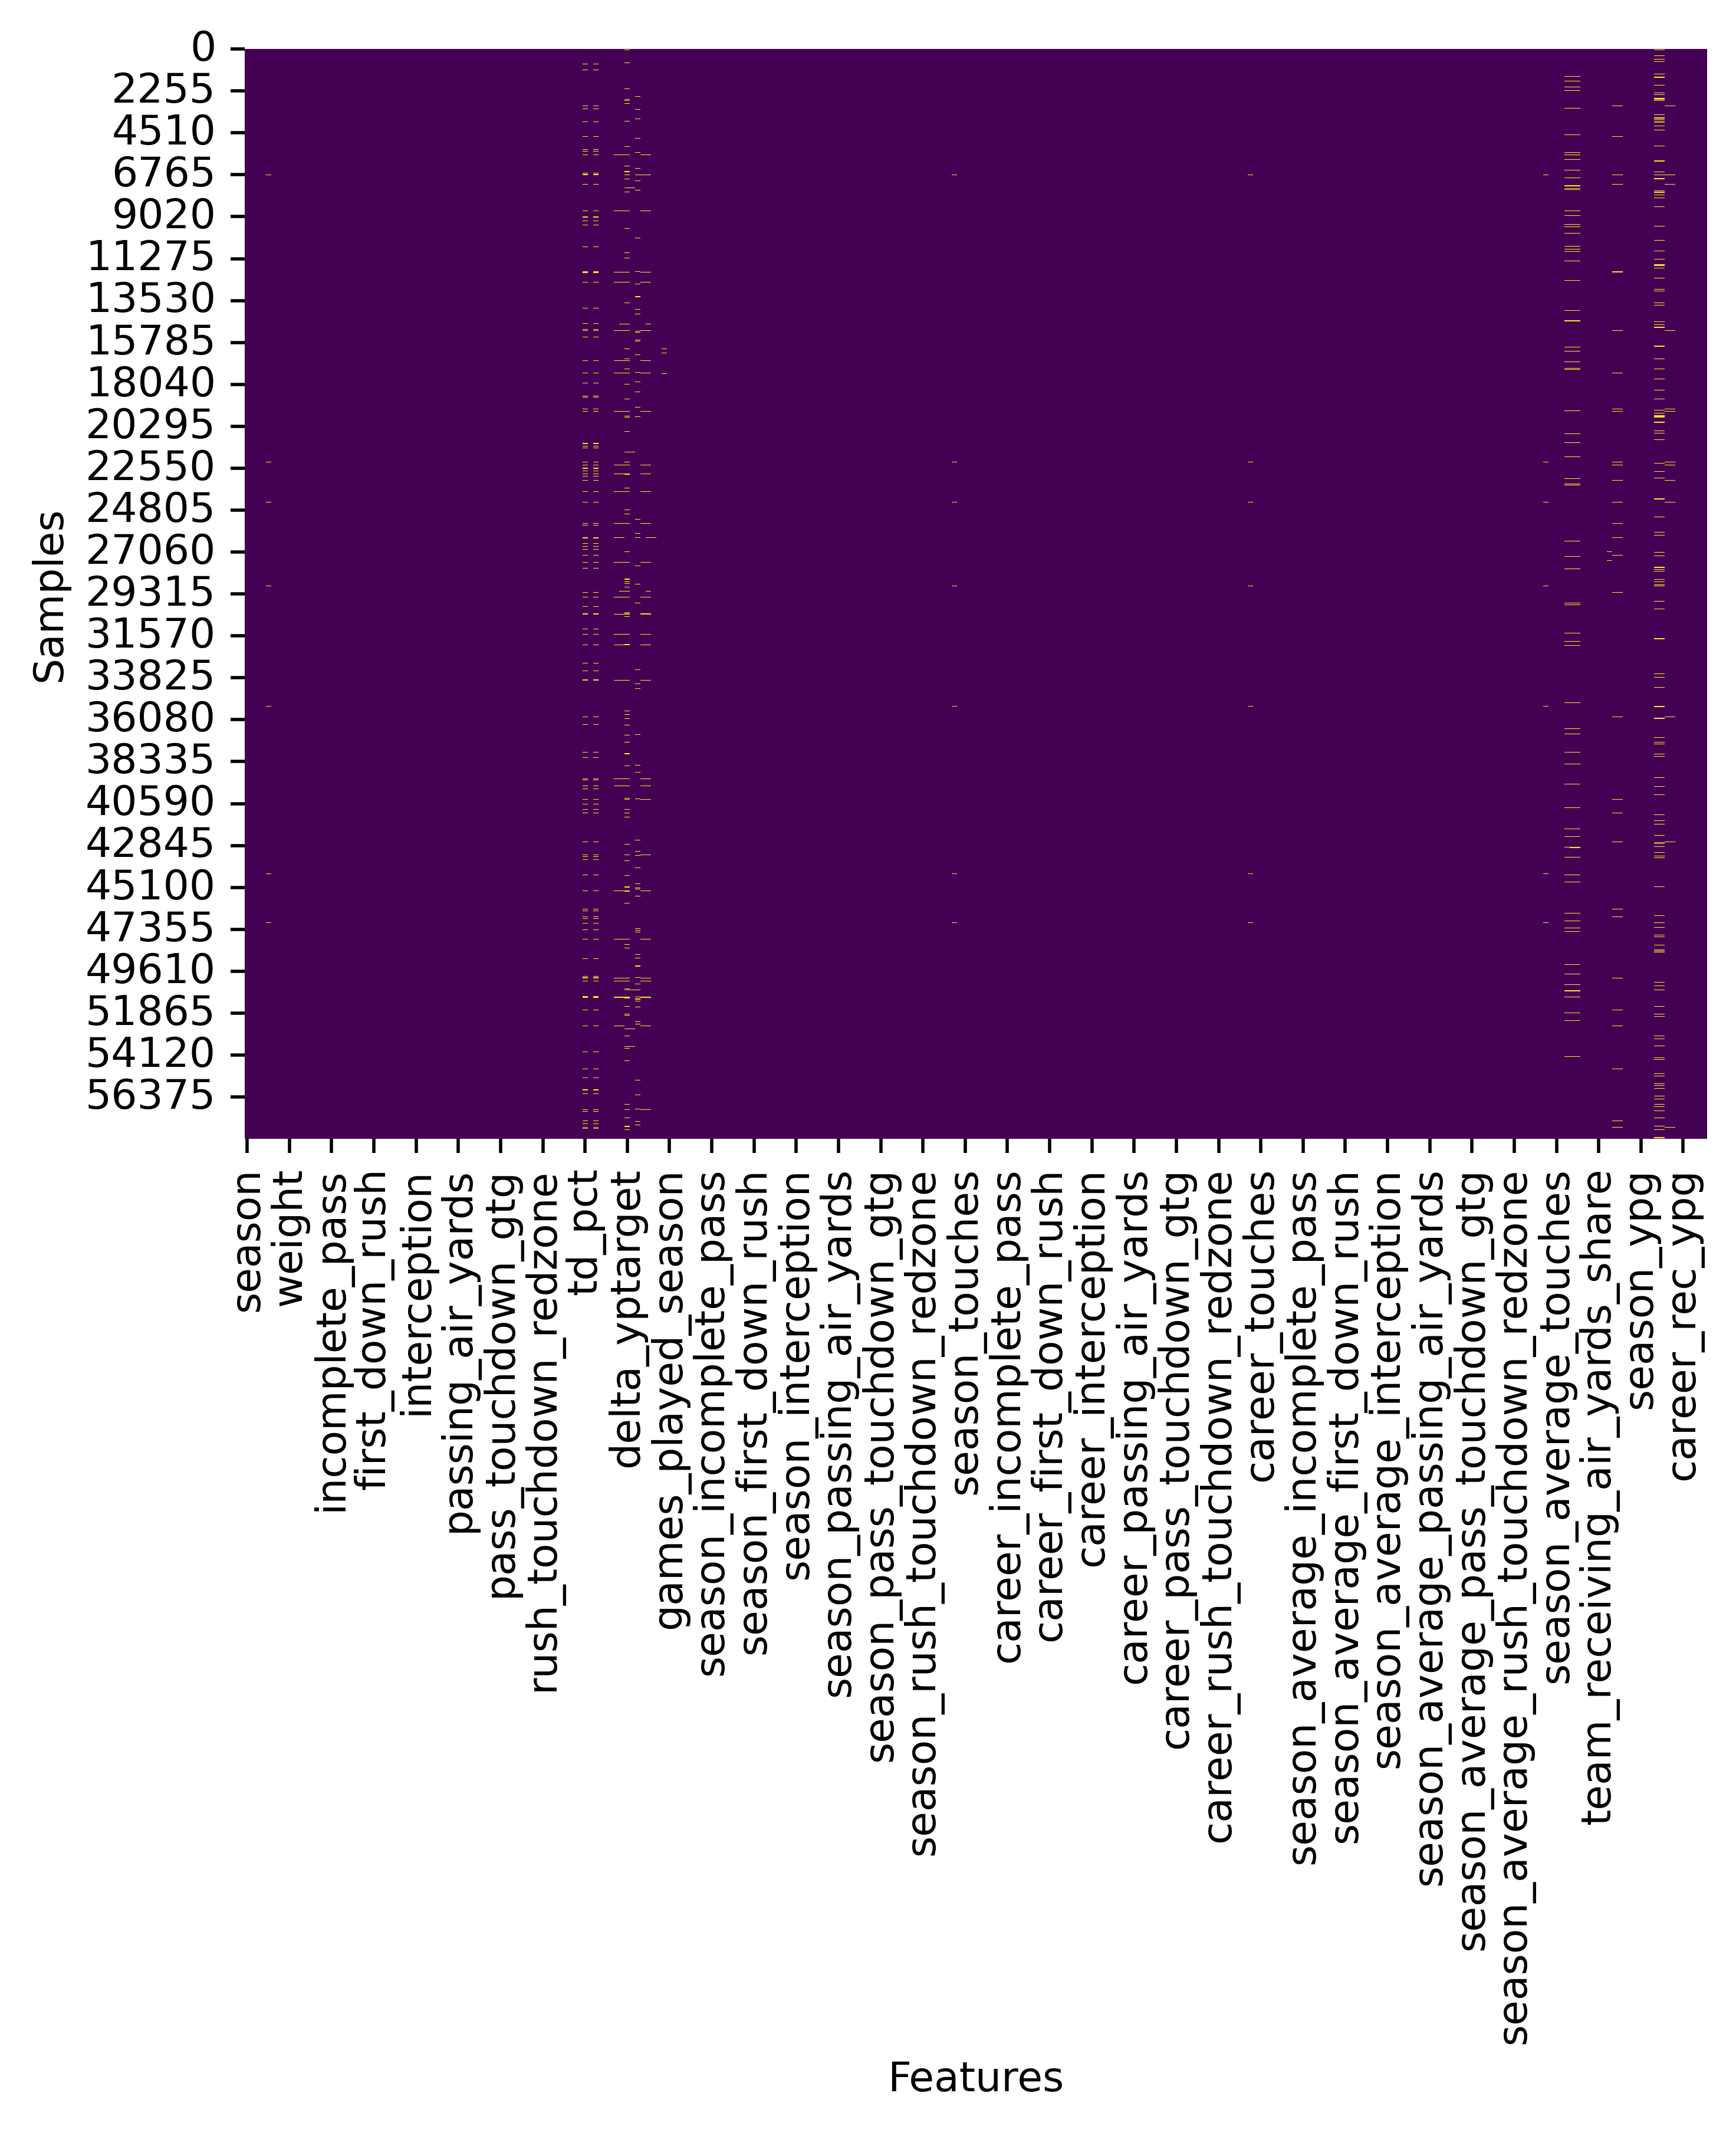

In [ ]:
# Creating a clean dataframe by dropping features with too many missing values
missing_threshold = 0.1  # Set threshold for missing values (e.g., 30%)
missing_fraction = raw_df.isnull().mean()
features_to_drop = missing_fraction[missing_fraction > missing_threshold].index
cleaned_df = raw_df.drop(columns=features_to_drop)
print("Dropped features due to missing values: ", features_to_drop.tolist())

# print("Cleaned DataFrame Features: ", cleaned_df.columns.tolist())

cleaned_categorical_features = [col for col in cleaned_df.columns if not pd.api.types.is_numeric_dtype(cleaned_df[col])]
cleaned_numerical_features = [col for col in cleaned_df.columns if pd.api.types.is_numeric_dtype(cleaned_df[col])]

# Print the heatmap of the cleaned dataframe numerical features
plt.figure(dpi=500)
sns.heatmap(cleaned_df[cleaned_numerical_features].isnull() , cbar=False , cmap='viridis')
plt.ylabel('Samples')
plt.xlabel('Features')
plt.show()